# Phase 5B: MRSCAtt (Mars Rover Spatial & Channel Attention CNN)
### Automated Classification of Martian Surface Images Captured by NASA's Curiosity Rover Using Machine Learning

---

## 1. Executive Summary & Objective

In Phase 5A, the pretrained ResNet-50 baseline achieved a test accuracy of **77.78%** and test Macro-F1 of **0.6631**, substantially outperforming Phase 4B's classical ML champion (47.20% accuracy).

**Phase 5B introduces MRSCAtt (Mars Rover Spatial and Channel Attention CNN)**:
- Augments ResNet-50 with a `ChannelSpatialBlock` placed immediately after `layer4`.
- **Channel Attention**: Captures inter-channel dependencies via dual global pooling (Average + Max) processed through separate linear projection branches (`avg_fc1/avg_fc2` and `max_fc1/max_fc2`) with BatchNorm1d and Dropout.
- **Spatial Attention**: Captures spatial location dependencies across the Martian terrain via channel-wise pooling and a $7 \times 7$ convolution.
- **Layer Freezing**: Backbone layers `conv1`, `bn1`, `layer1`, `layer2`, and `layer3` are frozen, while `layer4`, the attention block, and the classifier remain trainable.
- **Active Classes**: 24 active classes (Class 22 'sun' has 0 instances and is excluded).

In [1]:
import os
import sys
from pathlib import Path
import certifi
import json

# Ensure SSL certificates and project path
if 'SSL_CERT_FILE' not in os.environ:
    os.environ['SSL_CERT_FILE'] = certifi.where()

PROJECT_ROOT = Path('.').resolve().parent if Path('.').resolve().name == 'notebooks' else Path('.').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import config
from deep_learning import (
    load_synset_mapping,
    load_split_records,
    build_active_class_mappings,
    compute_training_class_weights,
    get_device
)
from deep_learning.models.mrscatt import build_mrscatt_model

print(f"PyTorch Version : {torch.__version__}")
device = get_device()
print(f"Active Device   : {device}")

PyTorch Version : 2.14.0
Active Device   : mps


## 2. Dataset Verification & Active Class Mapping

Programmatically verify the official NASA splits directly from `Mars rover data/`:

In [2]:
train_records = load_split_records(config.TRAIN_LABELS_PATH)
val_records = load_split_records(config.VAL_LABELS_PATH)
test_records = load_split_records(config.TEST_LABELS_PATH)

print(f"Train samples      : {len(train_records):,} (Expected: 3,746)")
print(f"Validation samples : {len(val_records):,} (Expected: 1,640)")
print(f"Test samples       : {len(test_records):,} (Expected: 1,305)")
print(f"Total images       : {len(train_records) + len(val_records) + len(test_records):,} (Expected: 6,691)")

assert len(train_records) == 3746
assert len(val_records) == 1640
assert len(test_records) == 1305

class_names = load_synset_mapping(config.CLASS_MAPPING_PATH)
orig_to_active, active_to_orig, active_to_name, active_classes = build_active_class_mappings(train_records, class_names)
print(f"\nActive classes     : {len(active_classes)} active classes (NASA IDs 0..21, 23, 24)")
print(f"Zero-sample class  : NASA ID 22 ('{class_names[22]}') correctly excluded from target space.")

Train samples      : 3,746 (Expected: 3,746)
Validation samples : 1,640 (Expected: 1,640)
Test samples       : 1,305 (Expected: 1,305)
Total images       : 6,691 (Expected: 6,691)

Active classes     : 24 active classes (NASA IDs 0..21, 23, 24)
Zero-sample class  : NASA ID 22 ('sun') correctly excluded from target space.


## 3. MRSCAtt Architecture & Parameter Freezing

We instantiate the MRSCAtt model and verify parameter counts and layer freezing:

In [3]:
model, meta = build_mrscatt_model(num_classes=24, pretrained=True, dropout_rate=0.2, apply_freezing=True)
print("MRSCAtt Model Architecture Details:")
for k, v in meta.items():
    print(f"  • {k:<26}: {v}")

# Forward pass check
dummy = torch.zeros(2, 3, 224, 224)
with torch.no_grad():
    out = model(dummy)
print(f"\nDummy forward check output shape: {out.shape} (Expected: (2, 24))")
assert out.shape == (2, 24)

MRSCAtt Model Architecture Details:
  • architecture              : MRSCAtt
  • backbone                  : ResNet-50
  • pretrained                : True
  • checkpoint                : ResNet50_Weights.DEFAULT (IMAGENET1K_V1)
  • attention_block           : ChannelSpatialBlock (Separate avg/max branches + 7x7 spatial conv)
  • input_resolution          : (224, 224)
  • num_classes               : 24
  • dropout_rate              : 0.2
  • total_parameters          : 24614588
  • trainable_parameters      : 16071292
  • frozen_parameters         : 8543296
  • freezing_configuration    : conv1, bn1, layer1..3 frozen; layer4, cbam, fc trainable

Dummy forward check output shape: torch.Size([2, 24]) (Expected: (2, 24))


## 4. Training History & Learning Curves

We load and visualize the 20-epoch training telemetry:

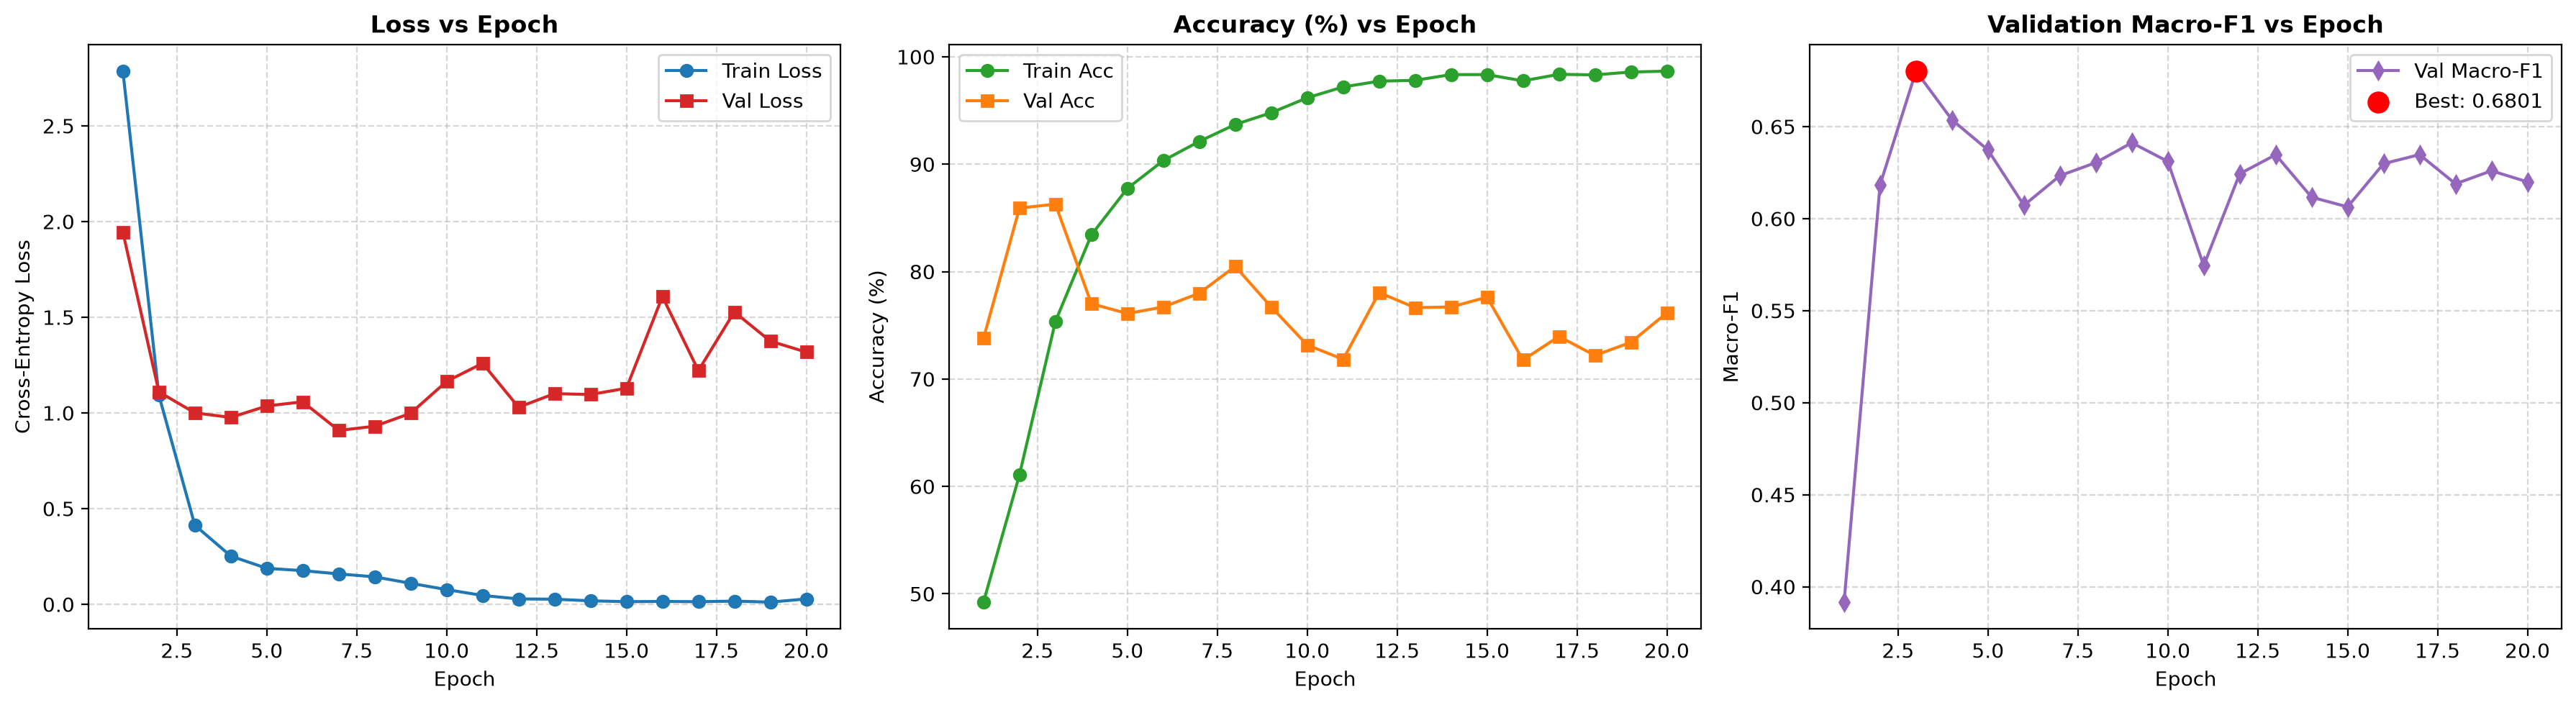

In [4]:
history_path = config.PHASE5B_LOGS_DIR / 'training_history.json'
if history_path.is_file():
    with open(history_path, 'r') as f:
        history = json.load(f)
    
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axs = plt.subplots(1, 3, figsize=(18, 5), dpi=200)
    
    # Loss
    axs[0].plot(epochs, history['train_loss'], 'o-', label='Train Loss', color='#1f77b4')
    axs[0].plot(epochs, history['val_loss'], 's-', label='Val Loss', color='#d62728')
    axs[0].set_title('Loss vs Epoch', fontweight='bold')
    axs[0].set_xlabel('Epoch')
    axs[0].set_ylabel('Cross-Entropy Loss')
    axs[0].grid(True, linestyle='--', alpha=0.5)
    axs[0].legend()
    
    # Accuracy
    axs[1].plot(epochs, history['train_acc'], 'o-', label='Train Acc', color='#2ca02c')
    axs[1].plot(epochs, history['val_acc'], 's-', label='Val Acc', color='#ff7f0e')
    axs[1].set_title('Accuracy (%) vs Epoch', fontweight='bold')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('Accuracy (%)')
    axs[1].grid(True, linestyle='--', alpha=0.5)
    axs[1].legend()
    
    # Macro-F1
    axs[2].plot(epochs, history['val_macro_f1'], 'd-', label='Val Macro-F1', color='#9467bd')
    best_idx = int(np.argmax(history['val_macro_f1']))
    axs[2].scatter([epochs[best_idx]], [history['val_macro_f1'][best_idx]], color='red', s=100, zorder=5, label=f'Best: {history["val_macro_f1"][best_idx]:.4f}')
    axs[2].set_title('Validation Macro-F1 vs Epoch', fontweight='bold')
    axs[2].set_xlabel('Epoch')
    axs[2].set_ylabel('Macro-F1')
    axs[2].grid(True, linestyle='--', alpha=0.5)
    axs[2].legend()
    
    plt.tight_layout()
    plt.show()
else:
    print("Training history not yet generated. Run run_phase5b.py first.")

## 5. Comparative Benchmark: Classical ML vs ResNet-50 vs MRSCAtt

We inspect the benchmark comparison across all three phases:

In [5]:
comp_csv = config.PHASE5B_METRICS_DIR / 'phase5a_vs_phase5b_comparison.csv'
if comp_csv.is_file():
    comp_df = pd.read_csv(comp_csv)
    display(comp_df)
else:
    print("Comparison CSV not yet generated. Run run_phase5b.py first.")

,Model,Input Representation,Val Macro-F1,Val Accuracy (%),Test Macro-F1,Test Accuracy (%),Test Macro Precision,Test Macro Recall,Test Weighted-F1
0,Phase 4B KNN-4 (Classical Champion),"8,186 Handcrafted Features + PCA-100",0.6613,50.85,0.5407,47.20,0.7103,0.5063,0.4386
1,Phase 5A ResNet-50 (Deep Learning Baseline),Raw Pixels (Letterbox 224x224 RGB),0.6673,83.72,0.6631,77.78,0.6886,0.7273,0.7937
2,Phase 5B MRSCAtt (Spatial & Channel Attention),Raw Pixels (Letterbox 224x224 RGB) + CBAM,0.6801,86.28,0.5851,64.29,0.6461,0.6553,0.6515
